In [1]:
# Reviewer: Alexander Volkovich.

import pandas as pd
from mlxtend.evaluate import accuracy_score

titanic = pd.read_csv("titanic.csv")
titanic = titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
titanic = titanic.dropna(subset=['Embarked'])

In [2]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(titanic.drop('Survived', axis=1), titanic['Survived'], shuffle=True,
                                                    test_size=0.2, random_state=42)
x_train.Embarked = x_train.Embarked.replace({'S': 0, 'C': 1, 'Q': 2})
x_test.Embarked = x_test.Embarked.replace({'S': 0, 'C': 1, 'Q': 2})
x_train.Age = x_train.Age.fillna(x_train.Age.median())
x_test.Age = x_test.Age.fillna(x_test.Age.median())


C:\Users\merda\AppData\Local\Temp\ipykernel_17624\1751324668.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_train.Embarked = x_train.Embarked.replace({'S': 0, 'C': 1, 'Q': 2})
C:\Users\merda\AppData\Local\Temp\ipykernel_17624\1751324668.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_test.Embarked = x_test.Embarked.replace({'S': 0, 'C': 1, 'Q': 2})


In [3]:
print((x_train.Pclass.value_counts() / len(x_train) -
 x_test.Pclass.value_counts() / len(x_test) < 0.05).sum() == len(titanic.Pclass.unique()))

True


In [4]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
standard_encoding = ['Age', 'Fare']
scaler.fit(x_train[standard_encoding])
encoded_df = pd.DataFrame(scaler.transform(x_train[standard_encoding]), columns=standard_encoding)

In [5]:
x_train.Sex = x_train.Sex.replace({'male': 0, 'female': 1})
x_test.Sex = x_test.Sex.replace({'male': 0, 'female': 1})
x_train[['Age', 'Fare']] = encoded_df[['Age', 'Fare']].values

C:\Users\merda\AppData\Local\Temp\ipykernel_17624\1589273281.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_train.Sex = x_train.Sex.replace({'male': 0, 'female': 1})
C:\Users\merda\AppData\Local\Temp\ipykernel_17624\1589273281.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_test.Sex = x_test.Sex.replace({'male': 0, 'female': 1})


In [6]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
k = 3
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [7]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
prediction = pd.DataFrame(knn.predict(x_test), columns=['Survived'])
score = accuracy_score(prediction, y_test)

In [8]:
from sklearn.model_selection import cross_val_score
scores = []
for i in range(1, 20):
    knn = KNeighborsClassifier(n_neighbors=i)
    scores.append(np.mean(cross_val_score(knn, x_train, y_train, cv=5, scoring='f1')))


In [9]:
optimal_k = scores.index(max(scores))
knn.fit(x_train, y_train)
confusion_matrix(y_test, knn.predict(x_test))
report = classification_report(y_test, knn.predict(x_test))

In [12]:
for i in range(len(x_train.columns) - 1):
    for j in range(1, 10):
        knn = KNeighborsClassifier(n_neighbors=j)
        scores.append(np.mean(cross_val_score(knn, x_train[x_train.columns[:1+i]], y_train, cv=5, scoring='accuracy')))
        knn.fit(x_train[x_train.columns[:1+i]], y_train)
cols = x_train.columns[:scores.index(max(scores)) // 10]
k = scores.index(max(scores)) + 1

In [13]:
knn = KNeighborsClassifier(n_neighbors=k)
scores.append(np.mean(cross_val_score(knn, x_train[cols], y_train, cv=5, scoring='accuracy')))
knn.fit(x_train[cols], y_train)


KNeighborsClassifier(n_neighbors=49)

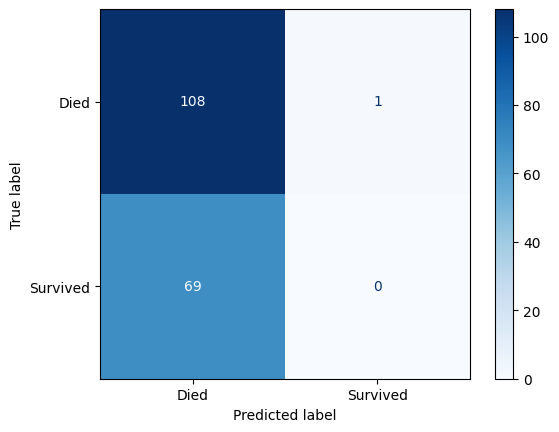

In [22]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, knn.predict(x_test[cols]))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Died','Survived']).plot(cmap='Blues')

[np.float64(0.6997014872014873),
 np.float64(0.6688442262471271),
 np.float64(0.7606497033599837),
 np.float64(0.7242607000972795),
 np.float64(0.7466418222601634),
 np.float64(0.7097673267326733),
 np.float64(0.7205971237398321),
 np.float64(0.6932232542139662),
 np.float64(0.7277372911794047),
 np.float64(0.7061550661416681),
 np.float64(0.7288674586113044),
 np.float64(0.7206000619986007),
 np.float64(0.7375971112631412),
 np.float64(0.7292567351019958),
 np.float64(0.7357731383449149),
 np.float64(0.7344433288885635),
 np.float64(0.7389762405568595),
 np.float64(0.7257415630825432),
 np.float64(0.7329218674407354)]